# Interpreting a 2-layer denoising network

Interpreting a 1-layer denoising network was an arbitrarily easy task and done so just to prove some neural networks are not black boxes. Interpreting a 2-layer network becomes much more difficult as it is not the case where we can simply inspect the weight matrices from each layer. This is because backpropogation does not require the order of the signal in-between the layers to remain, therefore the input into the second layer is completely "scrambled". We can't assess what goes in vs what goes out, because we essentially don't know what goes into that layer, or what transformation was done to it beforehand.

To this end, Kuprov et al developed a method to enforce ordering on the intermediate signals thus making proceeding layers interpretable. Details can be found in "Neural network interpretation using descrambler groups" https://arxiv.org/abs/1912.01498. We will use these results to demonstrate how a multilayer FCN can be interpreted, using the same denoising task.

The following is identical to the case of a 1 layer network:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import random


In [3]:
from nn_interpretation.signal_generator import signal_generator

num_instances = 10000
start = 0
end = 32.0
step = 0.2
noise_sigma = 0.1

x_data, y_data, signal_length = signal_generator(num_instances=num_instances, start=start, end=end, step=step, noise_sigma=noise_sigma)

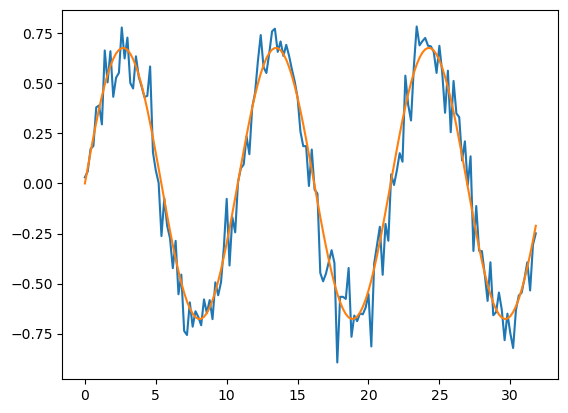

In [4]:
noisy = x_data[0:1].cpu().detach().numpy()
cleain = y_data[0:1].cpu().detach().numpy()
x = np.arange(0, 32, 0.2).reshape(1, -1)
plt.plot(x[0], noisy[0], label='Noisy')
plt.plot(x[0], cleain[0], label='Clean')


We now use a 2-layer network:

In [5]:
import torch
import torch.nn as nn

class net_2_layers(nn.Module):
    def __init__(self):
        super(net_2_layers, self).__init__()
        # Hidden layers (from previous step)
        self.fc1 = nn.Linear(signal_length, signal_length, bias=False)
        self.fc2 = nn.Linear(signal_length, signal_length, bias=False)
        
        # New Regression Layer
        # Maps from the hidden signal_length to the desired number of continuous outputs
        self.regressor = nn.Linear(signal_length, signal_length, bias=True)

    def forward(self, x):
        # Hidden Layer 1
        x = self.fc1(x)
        x = torch.tanh(x) 
        
        # Hidden Layer 2
        x = self.fc2(x)
        x = torch.tanh(x) 
        
        # Regression Layer (No activation function here)
        x = self.regressor(x)
        
        return x

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_2_layers = net_2_layers().to(device)
x_data = x_data.to(device)
y_data = y_data.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_2_layers.parameters(), lr=0.01)

# Number of params
pytorch_total_params = sum(p.numel() for p in model_2_layers.parameters() if p.requires_grad)
print(f'Number of parameters:{pytorch_total_params}')
print(signal_length)

Using device: cuda
Number of parameters:76960
160


In [7]:
# Training loop
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    outputs = model_2_layers(x_data)
    loss = criterion(outputs, y_data)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print loss
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [50/1000], Loss: 0.0023
Epoch [100/1000], Loss: 0.0018
Epoch [150/1000], Loss: 0.0014
Epoch [200/1000], Loss: 0.0011
Epoch [250/1000], Loss: 0.0008
Epoch [300/1000], Loss: 0.0008
Epoch [350/1000], Loss: 0.0007
Epoch [400/1000], Loss: 0.0007
Epoch [450/1000], Loss: 0.0008
Epoch [500/1000], Loss: 0.0008
Epoch [550/1000], Loss: 0.0006
Epoch [600/1000], Loss: 0.0006
Epoch [650/1000], Loss: 0.0007
Epoch [700/1000], Loss: 0.0007
Epoch [750/1000], Loss: 0.0007
Epoch [800/1000], Loss: 0.0007
Epoch [850/1000], Loss: 0.0006
Epoch [900/1000], Loss: 0.0006
Epoch [950/1000], Loss: 0.0005
Epoch [1000/1000], Loss: 0.0005


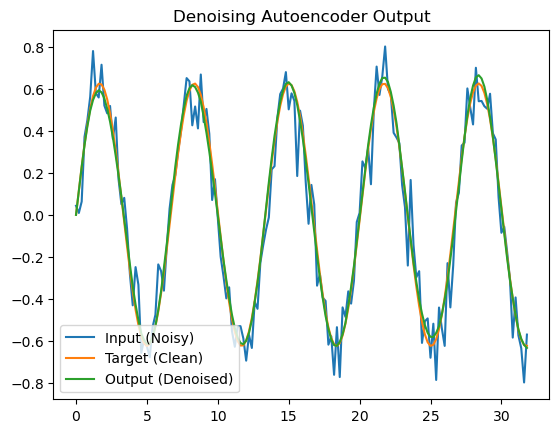

In [10]:
idx = 1
input = x_data[idx].unsqueeze(0)
target = y_data[idx].unsqueeze(0)
output = model_2_layers(input)

# Convert tensors to ndarrays
input_np = input.cpu().detach().numpy()
target_np = target.cpu().detach().numpy()
output_np = output.cpu().detach().numpy()

# Plotting
plt.figure()
plt.plot(x.T, input_np[0], label='Input (Noisy)')
plt.plot(x.T, target_np[0], label='Target (Clean)')
plt.plot(x.T, output_np[0], label='Output (Denoised)')
plt.legend()
plt.title('Denoising Autoencoder Output')
plt.show()

Scaled colour images of W1 (first layer weight) and W2 (second layer weight). Unlike the single layer network where you can instantly spot what the network is doing, here you can't.

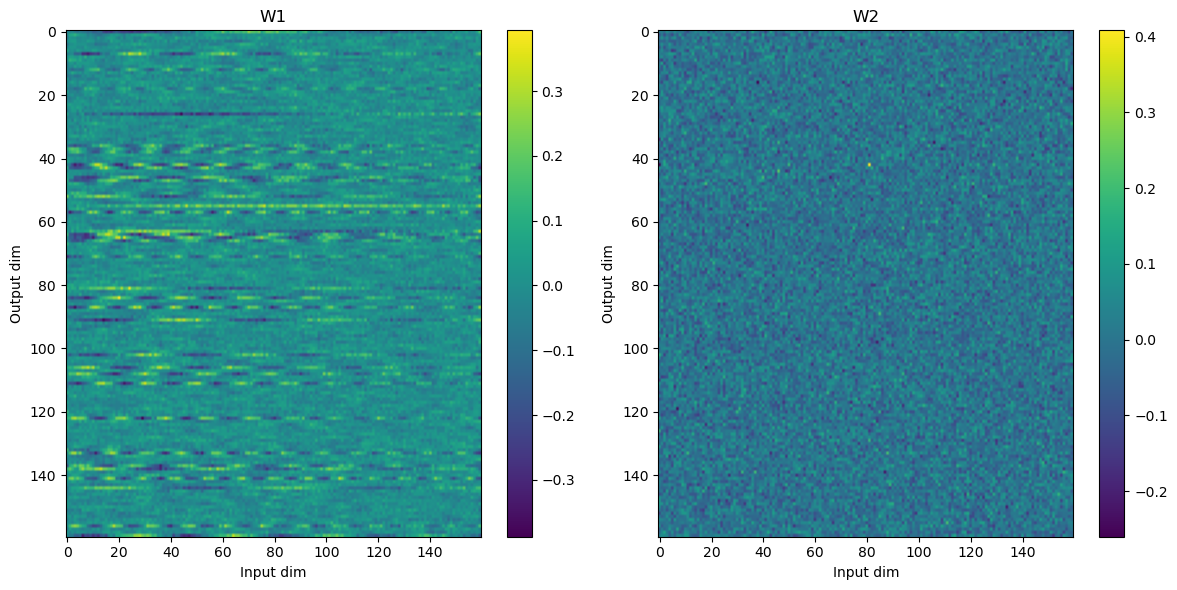

In [12]:
W1 = model_2_layers.fc1.weight.data
W1= W1.cpu().detach().numpy()

W2 = model_2_layers.fc2.weight.data
W2 = W2.cpu().detach().numpy()


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, W, title in zip(
    axes,
    [W1, W2],
    ['W1', 'W2']
):
    im = ax.imshow(W, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Input dim')
    ax.set_ylabel('Output dim')
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

Linear transformations carried out over several steps (e.g. in a neural network) can be collapsed down back into a single transformation. In theory we should be able to combine the two weights and see the same scaled colour image as with the single layer network, however this is not the case.

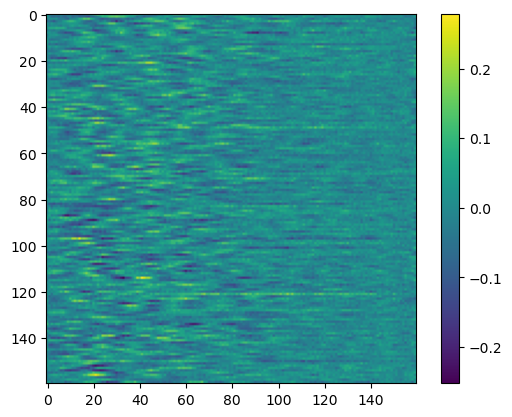

In [11]:
plt.imshow(W2@W1)
plt.colorbar()
plt.show()

In [12]:
import numpy as np
from scipy.optimize import minimize
from scipy.linalg import toeplitz, inv, norm

def get_fourdif_2nd_order(N):
    """
    Generates the 2nd order Fourier spectral differentiation matrix.
    Recreates the core functionality of MATLAB's fourdif(N, 2)
    based on standard spectral methods.
    """
    c = np.zeros(N)
    
    # Construct the first column of the Toeplitz matrix
    if N % 2 == 0:
        c[0] = -(N**2 + 2) / 12.0
        k = np.arange(1, N)
        c[1:] = 0.5 * ((-1)**k) / (np.sin(k * np.pi / N)**2)
    else:
        c[0] = -(N**2 - 1) / 12.0
        k = np.arange(1, N)
        c[1:] = 0.5 * ((-1)**k) * np.cos(k * np.pi / N) / (np.sin(k * np.pi / N)**2)
    
    # D is a symmetric Toeplitz matrix for the 2nd derivative
    D = toeplitz(c)
    return D

def descramble(S, n_iter=400, guess=None):
    """
    Generates a weight matrix descrambler for a particular layer in
    a neural network using Tikhonov smoothness criterion.
    
    Parameters:
        S (np.ndarray): A matrix containing, in its columns, the outputs
                        of the preceding layers of the neural network for
                        a (preferably large) number of reasonable inputs.
        n_iter (int): Maximum number of L-BFGS-B iterations. Default is 400.
        guess (np.ndarray): [optional] The initial guess for the descrambling
                            transform generator. Default is a zeros matrix.
                            
    Returns:
        P (np.ndarray): Descrambling matrix.
        Q (np.ndarray): Generator matrix.
    """
    # Check consistency
    if not isinstance(S, np.ndarray) or not np.isrealobj(S):
        raise ValueError("S must be a real numpy array.")
    if not isinstance(n_iter, int) or n_iter < 1:
        raise ValueError("n_iter must be a positive integer.")
        
    out_dim = S.shape[0]
    opt_dim = (out_dim**2 - out_dim) // 2
    
    # Lower triangle index array
    lt_idx = np.tril_indices(out_dim, -1)
    
    # Default guess is zero
    if guess is None:
        q0 = np.zeros(opt_dim)
    else:
        q0 = guess[lt_idx]
        
    # Get second derivative operator
    D = get_fourdif_2nd_order(out_dim)
    
    # Precompute some steps and scale
    SST = S @ S.T
    SST = out_dim * SST / norm(SST, 2)
    DTD = D.T @ D
    DTD = out_dim * DTD / norm(DTD, 2)
    U = np.eye(out_dim)
    
    # Regularisation signal (Objective Function)
    def reg_sig(q):
        # Form the generator
        Q = np.zeros((out_dim, out_dim))
        Q[lt_idx] = q
        Q = Q - Q.T
        
        # Re-use the inverse
        iUpQ = inv(U + Q)
        
        # Run Cayley transform
        P = iUpQ @ (U - Q)
        
        # Re-use triple product
        DTDPSST = DTD @ P @ SST
        
        # Compute Tikhonov norm
        eta = np.trace(DTDPSST @ P.T)
        
        # Compute Tikhonov norm gradient
        eta_grad = -2.0 * iUpQ.T @ DTDPSST @ (U + P).T
        
        # Antisymmetrise the gradient
        eta_grad = eta_grad - eta_grad.T
        
        # Extract the lower triangle
        eta_grad_1d = eta_grad[lt_idx]
        
        return eta, eta_grad_1d

    # Optimisation using L-BFGS-B 
    options = {
        'maxiter': n_iter,
        'disp': True, # Set to False to silence solver output
    }
    
    # Run the bounded memory BFGS minimizer
    res = minimize(reg_sig, q0, method='L-BFGS-B', jac=True, options=options)
    q_opt = res.x
    
    # Form descramble generator from the optimized values
    Q = np.zeros((out_dim, out_dim))
    Q[lt_idx] = q_opt
    Q = Q - Q.T
    
    # Run final Cayley transform
    P = inv(U + Q) @ (U - Q)
    
    return P, Q

In [13]:
S = W1 @ x_data.cpu().detach().numpy().T
P, Q = descramble(S, n_iter=1000)

C:\Users\tajwa\AppData\Local\Temp\ipykernel_13688\3950880391.py:109: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(reg_sig, q0, method='L-BFGS-B', jac=True, options=options)


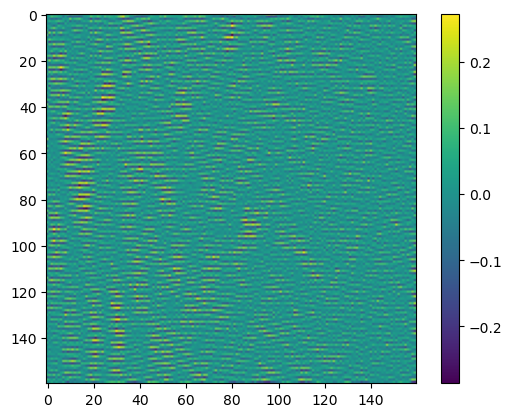

In [ ]:
# Subnet
Wd = P@W1

# Subnet training data

# Wd*all_inputs*tanh
# form new dataset with those outputs^
# Train against Y as before


In [28]:
# Convert Wd to a PyTorch tensor on the same device as x_data
Wd_tensor = torch.from_numpy(Wd).float().to(device)

# Apply Wd transformation followed by tanh activation
transformed_data = torch.tanh(x_data @ Wd_tensor.T)



In [29]:
class subnet(torch.nn.Module):

    def __init__(self):
        super(subnet, self).__init__()
        # Single hidden layer with no bias
        self.fc = nn.Linear(signal_length,signal_length, bias = False)

    def forward(self,x):
      x = self.fc(x)
      return x

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = subnet().to(device)
transformed_data = transformed_data.to(device)
y_data = y_data.to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Number of params
pytorch_total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Number of parameters:{pytorch_total_params}')
print(signal_length)

Using device: cuda
Number of parameters:25600
160


In [31]:
# Training loop
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(transformed_data)
    loss = criterion(outputs, y_data)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print loss
    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [50/1000], Loss: 0.0079
Epoch [100/1000], Loss: 0.0055
Epoch [150/1000], Loss: 0.0046
Epoch [200/1000], Loss: 0.0041
Epoch [250/1000], Loss: 0.0038
Epoch [300/1000], Loss: 0.0036
Epoch [350/1000], Loss: 0.0034
Epoch [400/1000], Loss: 0.0033
Epoch [450/1000], Loss: 0.0032
Epoch [500/1000], Loss: 0.0031
Epoch [550/1000], Loss: 0.0031
Epoch [600/1000], Loss: 0.0030
Epoch [650/1000], Loss: 0.0030
Epoch [700/1000], Loss: 0.0030
Epoch [750/1000], Loss: 0.0029
Epoch [800/1000], Loss: 0.0029
Epoch [850/1000], Loss: 0.0029
Epoch [900/1000], Loss: 0.0029
Epoch [950/1000], Loss: 0.0028
Epoch [1000/1000], Loss: 0.0028


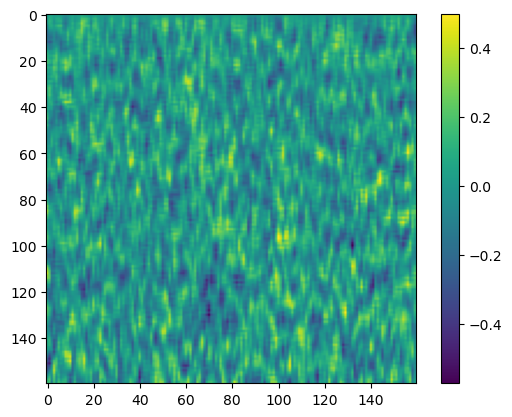

In [32]:
W_subnet = model.fc.weight.data
W_subnet = W_subnet.cpu().detach().numpy()

plt.imshow(W_subnet)
plt.colorbar()
plt.show()

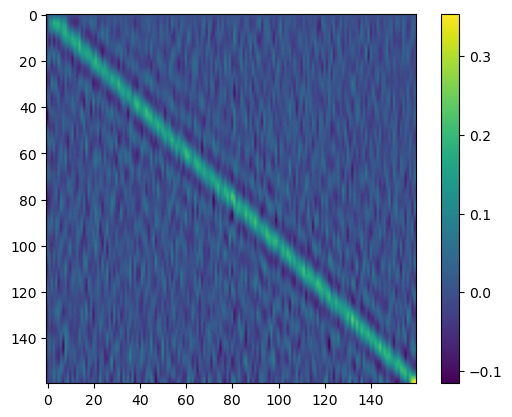

In [34]:
plt.imshow(W_subnet@Wd)
plt.colorbar()
plt.show()